# Importing libraries and dependancies 

In [35]:
# libraries
import pandas as pd # import pandas 
import numpy as np # import numpy 
import matplotlib.pyplot as plt # import matplotlib
import seaborn as sns # import seaborn  
%matplotlib inline
#import warnings
#warnings.filterwarnings('ignore')
#import os
#os.environ['KMP_DUPLICATE_LIB_OK']='True'   

# For statistical analysis especially hypothesis testing and regression analysis and time series analysis
##import scipy.stats as stats # import scipy stats
#import statsmodels.api as sm # import statsmodels api
#import statsmodels.formula.api as smf # import statsmodels formula api

# For machine learning
#import sklearn # import sklearn
#from sklearn.model_selection import train_test_split # import train test split
#from sklearn.linear_model import LinearRegression # import linear regression
#from sklearn.metrics import mean_squared_error, r2_score # import metrics





In [37]:
pd.__version__


'2.3.1'

In [38]:
np.__version__

'2.3.1'

In [ ]:
# load the dataset file onto   the working directory
#!wget https://raw.githubusercontent.com/alexeygrigorev/datasets/master/car_fuel_efficiency.csv

--2025-09-17 01:17:12--  https://raw.githubusercontent.com/alexeygrigorev/datasets/master/car_fuel_efficiency.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.


HTTP request sent, awaiting response... 200 OK
Length: 874188 (854K) [text/plain]
Saving to: ‘car_fuel_efficiency.csv.2’

car_fuel_efficiency 100%[===================>] 853.70K  3.28MB/s    in 0.3s    

2025-09-17 01:17:13 (3.28 MB/s) - ‘car_fuel_efficiency.csv.2’ saved [874188/874188]



In [41]:
# file path for the dataset
file = '/workspaces/mlzoom/01 Intro/Application/car_fuel_efficiency.csv'

In [42]:
# Load the data into a DataFrame for processing 
df = pd.read_csv(file)

In [43]:
#peek top five records
df.head()

,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,model_year,origin,fuel_type,drivetrain,num_doors,fuel_efficiency_mpg
0,170,3.0,159.0,3413.433759,17.7,2003,Europe,Gasoline,All-wheel drive,0.0,13.231729
1,130,5.0,97.0,3149.664934,17.8,2007,USA,Gasoline,Front-wheel drive,0.0,13.688217
2,170,NaN,78.0,3079.038997,15.1,2018,Europe,Gasoline,Front-wheel drive,0.0,14.246341
3,220,4.0,NaN,2542.392402,20.2,2009,USA,Diesel,All-wheel drive,2.0,16.912736
4,210,1.0,140.0,3460.870990,14.4,2009,Europe,Gasoline,All-wheel drive,2.0,12.488369


In [44]:
# Number of records in df
df.shape

(9704, 11)

# EDA to check linear regresion assupmtion:
    # Linearity,Multicollinearity,and outliers 
    # NB: Homoskedacity,independence of errors,and normality of errors will be checked after fitting 


In [ ]:
# Check data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9704 entries, 0 to 9703
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   engine_displacement  9704 non-null   int64  
 1   num_cylinders        9222 non-null   float64
 2   horsepower           9704 non-null   float64
 3   vehicle_weight       9704 non-null   float64
 4   acceleration         8774 non-null   float64
 5   model_year           9704 non-null   int64  
 6   origin               9704 non-null   object 
 7   fuel_type            9704 non-null   object 
 8   drivetrain           9704 non-null   object 
 9   num_doors            9202 non-null   float64
 10  fuel_efficiency_mpg  9704 non-null   float64
dtypes: float64(6), int64(2), object(3)
memory usage: 834.1+ KB


# Brief backgroung about the target variable : 
#(NB: THE INFO IS COPIED DIRECTLY FORM REFRENCES 1 AND 2 BELOW)
    
    #defination(fuel ) : Fuel economy is defined as the number of miles driven per gallon of gasoline consumed, commonly referred to as miles per gallon #(MPG). It is influenced by factors such as the size, shape, and weight of the vehicle, as well as driving conditions[1]. 

#NOTE: Fuel consumption is a more accurate measure of a vehicle's performance because it is a linear relationship while fuel economy leads to           #distortions in efficiency improvements.[2] Weight-specific efficiency (efficiency per unit weight) may be stated for freight, and passenger-specific # #efficiency (vehicle efficiency per passenger) for passenger vehicles[2].
# References : 
#1. https://www.sciencedirect.com/topics/engineering/fuel-economy#:~:text=In%20subject%20area:%20Engineering,Definition

#2. https://en.wikipedia.org/wiki/Fuel_efficiency

In [50]:
# segment df columns into categorical and numerical columns

cat_cols = df.select_dtypes(include=['object']).columns # Categorical columns
num_cols = df.select_dtypes(include=['number']).columns # Numerical columns


In [51]:
cat_cols

Index(['origin', 'fuel_type', 'drivetrain'], dtype='object')

In [52]:
num_cols

Index(['engine_displacement', 'num_cylinders', 'horsepower', 'vehicle_weight',
       'acceleration', 'model_year', 'num_doors', 'fuel_efficiency_mpg'],
      dtype='object')

In [45]:
# Check for missing values
#ALSO CORESPONDES TO Q4:

# Missin values in df
#Q4. Missing values
#How many columns in the dataset have missing values?
df.isna().sum()

engine_displacement      0
num_cylinders          482
horsepower             708
vehicle_weight           0
acceleration           930
model_year               0
origin                   0
fuel_type                0
drivetrain               0
num_doors              502
fuel_efficiency_mpg      0
dtype: int64

In [ ]:
# UNI AND BIVARIATE ANALYSIS
    # The goal is to understand the distribution of the target variable and the relationships between the target variable and the features.
    # spot skewness, outliers, and other patterns that may affect the modeling process.
    # Univariate analysis of the target variable 'mpg'

# Summary statistics of numerical columns
df.describe()

,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,model_year,num_doors,fuel_efficiency_mpg
count,9704.000000,9222.000000,8996.000000,9704.000000,8774.000000,9704.000000,9202.000000,9704.000000
mean,199.708368,3.962481,149.657292,3001.280993,15.021928,2011.484027,-0.006412,14.985243
std,49.455319,1.999323,29.879555,497.894860,2.510339,6.659808,1.048162,2.556468
min,10.000000,0.000000,37.000000,952.681761,6.000000,2000.000000,-4.000000,6.200971
25%,170.000000,3.000000,130.000000,2666.248985,13.300000,2006.000000,-1.000000,13.267459
50%,200.000000,4.000000,149.000000,2993.226296,15.000000,2012.000000,0.000000,15.006037
75%,230.000000,5.000000,170.000000,3334.957039,16.700000,2017.000000,1.000000,16.707965
max,380.000000,13.000000,271.000000,4739.077089,24.300000,2023.000000,4.000000,25.967222


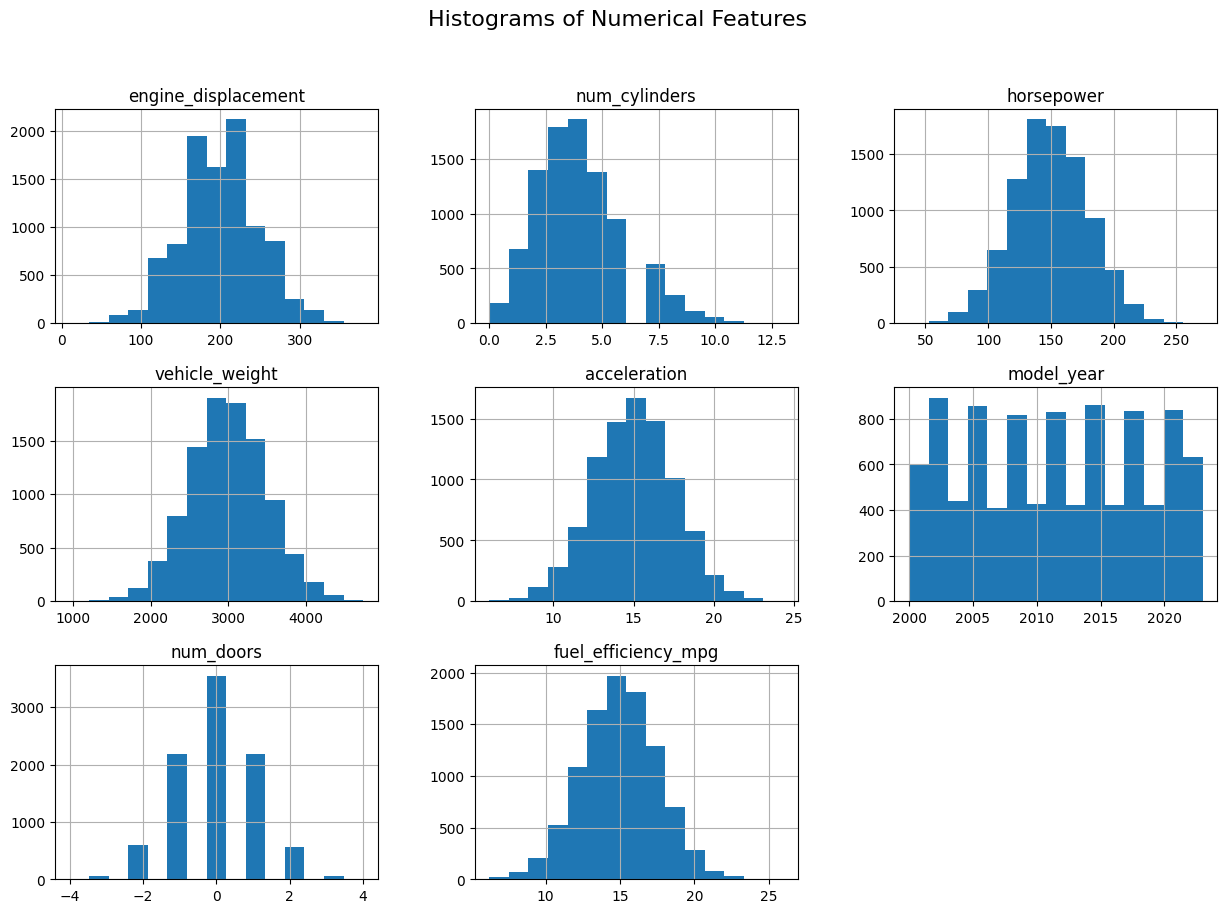

In [54]:
df[num_cols].hist(bins=15, figsize=(15, 10))
plt.suptitle('Histograms of Numerical Features', fontsize=16)
plt.show()

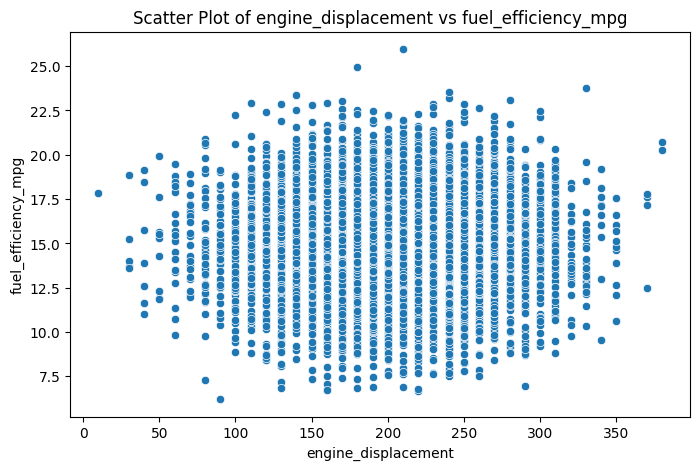

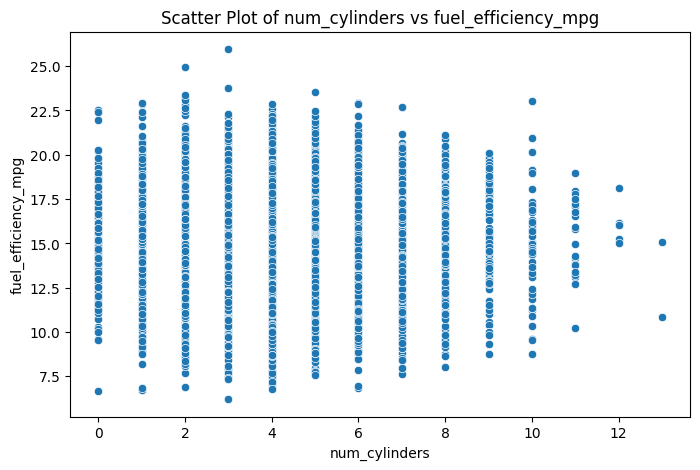

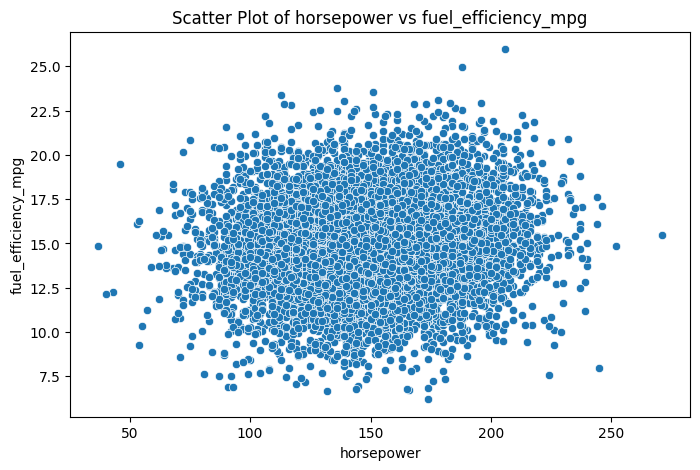

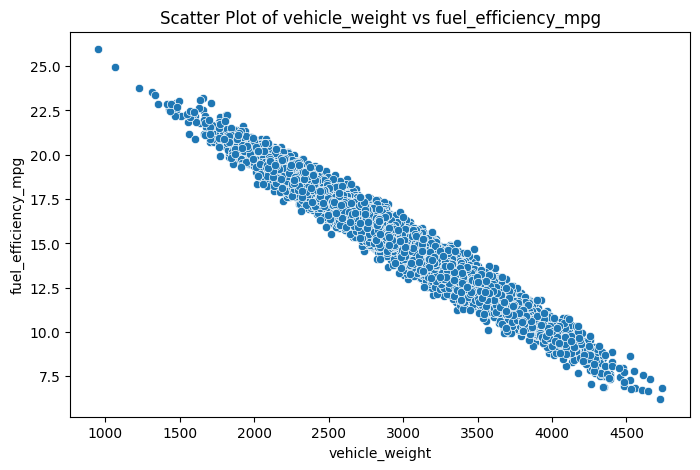

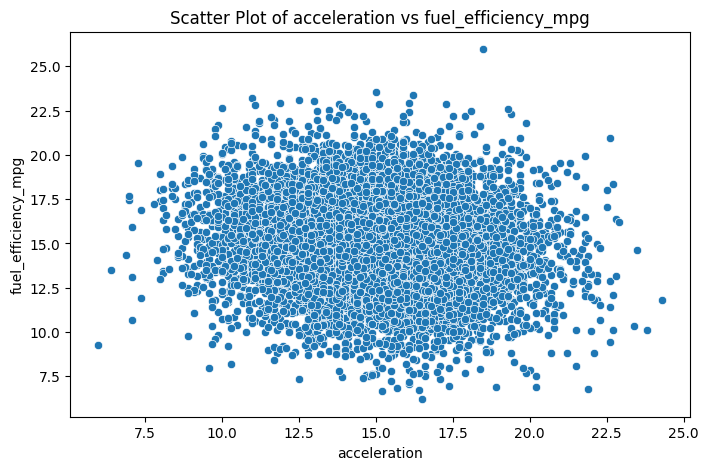

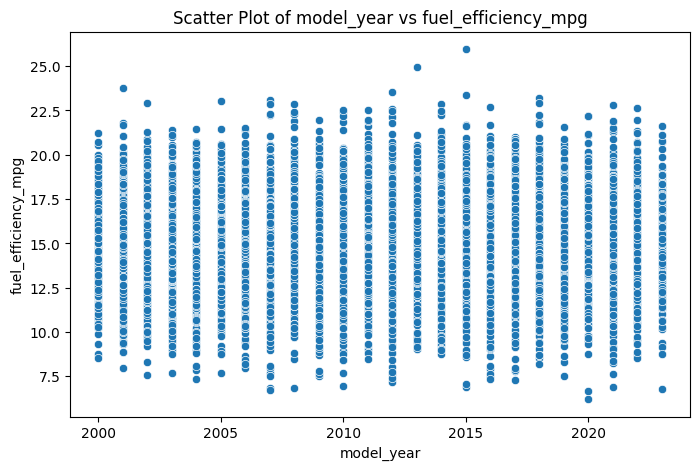

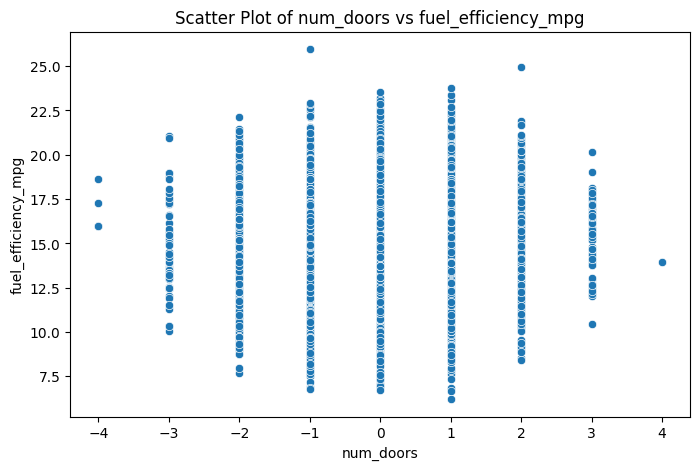

In [ ]:
# scatter plots of numerical features against the target variable fuel_efficiency_mpg
for col in num_cols:
    if col != 'fuel_efficiency_mpg':
        plt.figure(figsize=(8, 5))
        sns.scatterplot(data=df, x=df[col], y=df['fuel_efficiency_mpg'])
        plt.title(f'Scatter Plot of {col} vs fuel_efficiency_mpg')
        plt.xlabel(col)
        plt.ylabel('fuel_efficiency_mpg')
        plt.show()

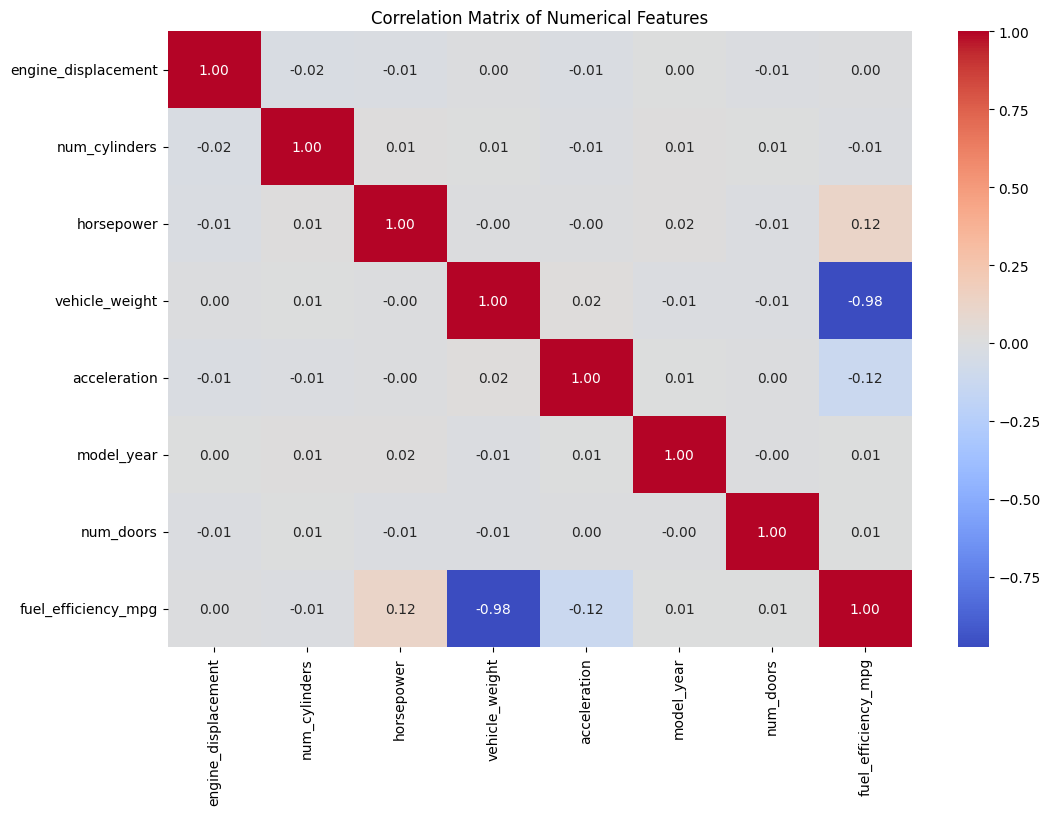

In [60]:
# heatmap to visualize correlations
plt.figure(figsize=(12, 8))
corr_matrix = df[num_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Matrix of Numerical Features')       
plt.show()

# Notes and concluion on EDA on num_cols
## 

In [70]:
# Frequency counts of categorical columns
for col in cat_cols:
    print(df[col].value_counts())   

origin
Europe    3254
Asia      3247
USA       3203
Name: count, dtype: int64
fuel_type
Gasoline    4898
Diesel      4806
Name: count, dtype: int64
drivetrain
All-wheel drive      4876
Front-wheel drive    4828
Name: count, dtype: int64


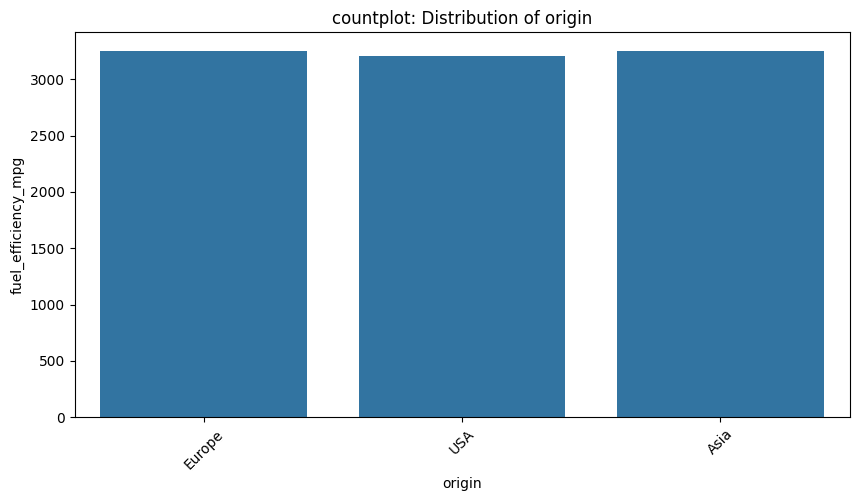

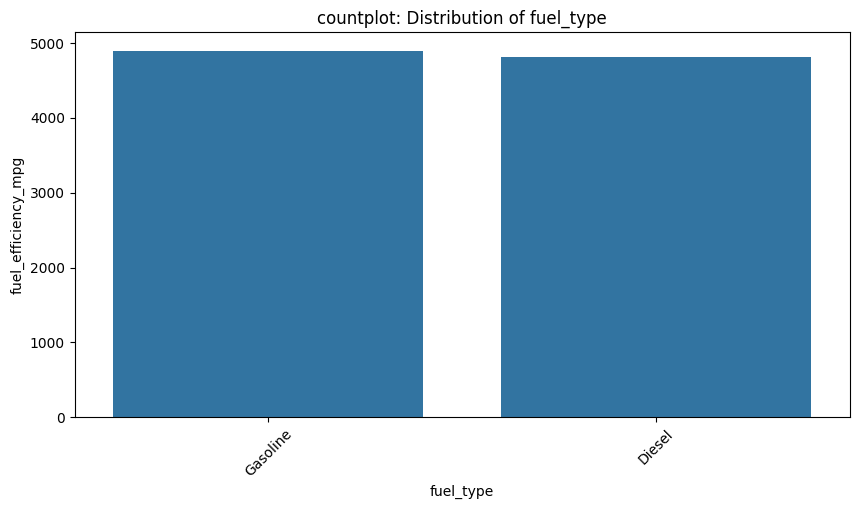

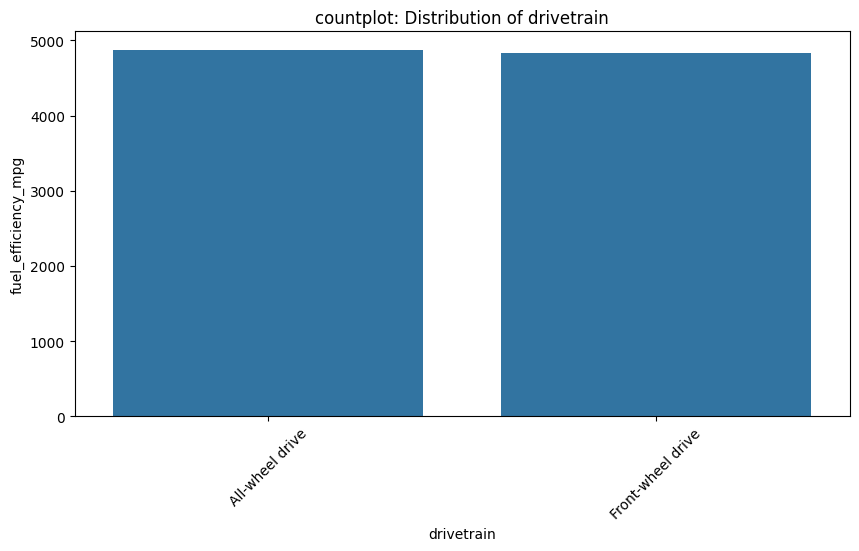

In [ ]:
# For the categorical variables frequency we will use count plots to see the feature  distribution
for col in cat_cols:
    plt.figure(figsize=(10, 5))
    sns.countplot(data=df, x=df[col])
    plt.title(f'countplot: Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('fuel_efficiency_mpg')
    plt.xticks(rotation=45)
    plt.show()




In [ ]:
#Q3. Fuel types
#How many fuel types are presented in the dataset?
df['fuel_type'].value_counts()

fuel_type
Gasoline    4898
Diesel      4806
Name: count, dtype: int64

In [14]:
# df columns names

df.columns



Index(['engine_displacement', 'num_cylinders', 'horsepower', 'vehicle_weight',
       'acceleration', 'model_year', 'origin', 'fuel_type', 'drivetrain',
       'num_doors', 'fuel_efficiency_mpg'],
      dtype='object')

In [20]:
#Q5. Max fuel efficiency
#What's the maximum fuel efficiency of cars from Asia?

df[['origin','fuel_efficiency_mpg']][df['origin'] =='Asia'].max()

origin                      Asia
fuel_efficiency_mpg    23.759123
dtype: object

#Question 6. Median value of horsepower (1 point)
#Q6. Median value of horsepower
    # Find the median value of horsepower column in the dataset.
    # Next, calculate the most frequent value of the same horsepower column.
    # Use fillna method to fill the missing values in horsepower column with the most frequent value from the previous step.
    # Now, calculate the median value of horsepower once again.
        # Has it changed?
        # Yes, it increased
        # Yes, it decreased
        # No


In [24]:
 # Find the median value of horsepower column in the dataset.
 df['horsepower'].median(numeric_only=True)

np.float64(149.0)

In [ ]:
# Next, calculate the most frequent value of the same horsepower column.
df['horsepower'].mode()

0    152.0
Name: horsepower, dtype: float64

In [30]:
# Use fillna method to fill the missing values in horsepower column with the most frequent value from the previous step.
df['horsepower'].fillna(df['horsepower'].mode()[0],inplace =True)


/tmp/ipykernel_2793/4252760884.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['horsepower'].fillna(df['horsepower'].mode()[0],inplace =True)


In [ ]:
 # Now, calculate the median value of horsepower once again.
 # And determine if :
        # Has it changed?
        # Yes, it increased
        # Yes, it decreased
        # No
 
df['horsepower'].median(numeric_only=True)

np.float64(152.0)

# Q7. Sum of weights

#Select all the cars from Asia
#Select only columns vehicle_weight and model_year
#Select the first 7 values
#Get the underlying NumPy array. Let's call it X.
#Compute matrix-matrix multiplication between the transpose of X and X. To get the transpose, use X.T. Let's call the result XTX.
#Invert XTX.
#Create an array y with values [1100, 1300, 800, 900, 1000, 1100, 1200].
#Multiply the inverse of XTX with the transpose of X, and then multiply the result by y. Call the result w.
#What's the sum of all the elements of the result?

In [71]:
#Select all the cars from Asia
df_asia = df[df['origin']=='Asia']
df_asia.head()

,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,model_year,origin,fuel_type,drivetrain,num_doors,fuel_efficiency_mpg
8,250,1.0,174.0,2714.219310,10.3,2016,Asia,Diesel,Front-wheel drive,-1.0,16.823554
12,320,5.0,145.0,2783.868974,15.1,2010,Asia,Diesel,All-wheel drive,1.0,16.175820
14,200,6.0,160.0,3582.687368,14.9,2007,Asia,Diesel,All-wheel drive,0.0,11.871091
20,150,3.0,197.0,2231.808142,18.7,2011,Asia,Gasoline,Front-wheel drive,1.0,18.889083
21,160,4.0,133.0,2659.431451,NaN,2016,Asia,Gasoline,Front-wheel drive,-1.0,16.077730


In [76]:
#Select only columns vehicle_weight and model_year

df_asia = df_asia[['vehicle_weight','model_year']] 
df_asia.head(7)

,vehicle_weight,model_year
8,2714.219310,2016
12,2783.868974,2010
14,3582.687368,2007
20,2231.808142,2011
21,2659.431451,2016
34,2844.227534,2014
38,3761.994038,2019


In [78]:
#Select the first 7 values
df_asia.iloc[:7]

,vehicle_weight,model_year
8,2714.219310,2016
12,2783.868974,2010
14,3582.687368,2007
20,2231.808142,2011
21,2659.431451,2016
34,2844.227534,2014
38,3761.994038,2019


In [85]:
#Get the underlying NumPy array. Let's call it X.


import numpy as np # import numpy

X = np.array(df_asia[['vehicle_weight','model_year']].iloc[:7])
X

array([[2714.21930965, 2016.        ],
       [2783.86897424, 2010.        ],
       [3582.68736772, 2007.        ],
       [2231.8081416 , 2011.        ],
       [2659.43145076, 2016.        ],
       [2844.22753389, 2014.        ],
       [3761.99403819, 2019.        ]])

In [87]:
X.ndim

2

In [88]:
# Compute matrix-matrix multiplication between the transpose of X and X.
# To get the transpose, use X.T. Let's call the result XTX.

XTX  = np.dot(X.T,X)

In [89]:
# Due to the requirement of the next step-to compute the inverse of XTX. 
# Our numpy matrix must be square.
# Hence the function to check if the matrix is square below.
def is_square_numpy_matrix(matrix):
    """Takes a numpy matrix as input ,checks if it is square and returns a True or False value"""
    if not isinstance(matrix, np.ndarray): 
        raise TypeError("Input must be a NumPy array.")
    
    if matrix.ndim != 2:  # Ensure it's a 2D matrix
        return False
        
    rows, cols = matrix.shape
    return rows == cols


In [90]:
is_square_numpy_matrix(XTX)

True

In [91]:
#Compute the inverse of XTX.

XTX_inv = np.linalg.inv(XTX)

In [93]:
#Create an array y with values [1100, 1300, 800, 900, 1000, 1100, 1200].


y = np.array([1100, 1300, 800, 900, 1000, 1100, 1200])
y

array([1100, 1300,  800,  900, 1000, 1100, 1200])

In [94]:
#Multiply the inverse of XTX with the transpose of X, and then multiply the result by y. Call the result w.
#What's the sum of all the elements of the result?

w = np.dot(np.dot(XTX_inv,X.T),y)



In [97]:
w.sum()

np.float64(0.5187709081074016)